# Prediction de note utilisateur — endpoint `/prediction`

**Personne B — ML & NLP Engineer.** Notebook end-to-end : EDA, baselines,
split, validation croisee, entrainement LightGBM et SVD, comparaison,
interpretation SHAP, analyse des erreurs, conclusion.

**Seuils cibles** (feuille de route equipe) : RMSE < 1.0 et amelioration
>= 10% vs baseline naive.

Ce notebook importe les fonctions pures de `ml/training/features.py` et les
fonctions d'entrainement de `ml/training/model.py` : aucune logique n'est
dupliquee ici, seulement de la documentation et de l'analyse.

In [1]:
import sys
from datetime import date
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from ml.training import features, model

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (8, 4)

C:\Users\mapp\CineMatch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Chargement des donnees Gold

In [2]:
notation_df, film_df = model.load_gold_data()
print(f"{len(notation_df)} notations, {len(film_df)} films")
notation_df.head()

1000209 notations, 3883 films


,user_id,film_id,note,timestamp
0,6040,858,4.0,956703932
1,6040,2384,4.0,956703954
2,6040,593,5.0,956703954
3,6040,1961,4.0,956703977
4,6040,2019,5.0,956703977


## 2. EDA (repris de `ml/training/eda_exploration.py`)

Rappel synthetique des constats deja etablis, recalcules ici pour que le
notebook soit auto-suffisant.

### 2.1 Volumetrie

In [3]:
n_notations = len(notation_df)
n_users = notation_df["user_id"].nunique()
n_films_notes = notation_df["film_id"].nunique()
print(f"Notations            : {n_notations}")
print(f"Utilisateurs distincts: {n_users}")
print(f"Films distincts (notes): {n_films_notes} (sur {len(film_df)} au catalogue)")

Notations            : 1000209
Utilisateurs distincts: 6040
Films distincts (notes): 3706 (sur 3883 au catalogue)


**Interpretation** : ~1M notations (MovieLens 1M), 6 040 utilisateurs, 3 706
films notes sur 3 883 au catalogue. Volume suffisant pour entrainer un modele
supervise avec des agregats user/film robustes.

### 2.2 Distribution des notes

In [4]:
dist_pct = (notation_df["note"].value_counts(normalize=True).sort_index() * 100).round(1)
print(dist_pct)
print(f"\nMoyenne={notation_df['note'].mean():.3f}  Ecart-type={notation_df['note'].std():.3f}")

note
1.0     5.6
2.0    10.8
3.0    26.1
4.0    34.9
5.0    22.6
Name: proportion, dtype: float64

Moyenne=3.582  Ecart-type=1.117


**Interpretation** : distribution biaisee vers les notes hautes (3-4-5
represente ~83% des notes), moyenne ~3.58. Cela justifie la baseline
"moyenne globale" comme reference minimale, et suggere qu'un modele naif
predisant toujours ~3.6 aura deja un RMSE modere.

### 2.3 Sparsite de la matrice user x film

In [5]:
taille_matrice = n_users * n_films_notes
densite = n_notations / taille_matrice
print(f"Taille matrice : {n_users} x {n_films_notes} = {taille_matrice}")
print(f"Densite  : {densite:.4%}")
print(f"Sparsite : {1 - densite:.4%}")

Taille matrice : 6040 x 3706 = 22384240
Densite  : 4.4684%
Sparsite : 95.5316%


**Interpretation** : ~95.5% de sparsite. Un collaborative filtering pur (SVD)
doit composer avec une matrice tres creuse -> justifie l'usage d'une
factorisation biaisee (moyenne globale + biais user/film) plutot qu'une SVD
brute, et motive l'approche LightGBM base sur des agregats plutot qu'une
matrice user-item explicite.

### 2.4 Utilisateurs / films a faible signal (< 5 notations)

In [6]:
MIN_NOTATIONS = 5
user_counts = notation_df.groupby("user_id").size()
film_counts = notation_df.groupby("film_id").size()
n_users_low = int((user_counts < MIN_NOTATIONS).sum())
n_films_low = int((film_counts < MIN_NOTATIONS).sum())
low_signal_film_ids = set(film_counts[film_counts < MIN_NOTATIONS].index)

print(f"Utilisateurs < {MIN_NOTATIONS} notations : {n_users_low} / {n_users}")
print(f"Films < {MIN_NOTATIONS} notations         : {n_films_low} / {n_films_notes}")

Utilisateurs < 5 notations : 0 / 6040
Films < 5 notations         : 290 / 3706


**Interpretation** : 0 utilisateur a faible activite (MovieLens garantit un
minimum par construction) mais **290 films** (~7.8%) ont moins de 5
notations. Ces films a faible signal seront revisites dans la section
"Analyse des erreurs" : on s'attend a un RMSE plus eleve dessus (peu
d'exemples pour apprendre leur biais).

### 2.5 Couverture des colonnes TMDB (table `film`)

In [7]:
tmdb_cols = ["overview", "popularite", "note_tmdb", "affiche_path"]
for col in tmdb_cols:
    coverage = film_df[col].notna().mean() * 100
    print(f"  {col:<15}: {coverage:5.1f}% de couverture")

  overview       :  43.9% de couverture
  popularite     :  43.9% de couverture
  note_tmdb      :  43.9% de couverture


  affiche_path   :  43.8% de couverture


**Interpretation** : ~44% de couverture, identique sur les 4 colonnes (meme
sous-ensemble de films enrichi via l'API TMDB). Confirme la necessite d'un
flag explicite `has_tmdb_data` + imputation (jamais de `dropna`), implementes
dans `ml/training/features.py`. La section SHAP plus bas quantifiera si ces
features apportent reellement du signal au modele.

## 3. Split train/test stratifie par utilisateur

Chaque utilisateur retrouve la meme proportion de ses notations dans le
train (80%) et le test (20%) : pas de cold-start artificiel, tout en testant
sur des couples (user, film) jamais vus a l'entrainement. Verification
explicite qu'aucune paire (user, film) ne fuite entre les deux ensembles.

In [8]:
train_notation, test_notation = features.stratified_user_train_test_split(
    notation_df, test_size=0.2, random_state=42
)
print(f"train={len(train_notation)}  test={len(test_notation)}")

train_pairs = set(zip(train_notation["user_id"], train_notation["film_id"]))
test_pairs = set(zip(test_notation["user_id"], test_notation["film_id"]))
assert train_pairs.isdisjoint(test_pairs), "Fuite detectee entre train et test !"
print("OK : aucune fuite (user, film) entre train et test.")

train=800167  test=200042


OK : aucune fuite (user, film) entre train et test.


## 4. Baselines naives

Deux baselines, calculees sur le train et evaluees sur le test :
- **Moyenne globale** : prediction constante = moyenne des notes du train.
- **Moyenne par film** : prediction = moyenne des notes du film dans le train
  (fallback moyenne globale pour un film absent du train — cold-start).

In [9]:
context = model.build_feature_context(train_notation, film_df)
train_matrix = model.build_matrix(train_notation, context)
test_matrix = model.build_matrix(test_notation, context)

assert not train_matrix[context.feature_cols].isna().any().any()
assert not test_matrix[context.feature_cols].isna().any().any()
print("OK : aucune valeur manquante dans les features (pas de dropna).")

baseline_metrics = model.evaluate_baselines(test_matrix, context.global_mean)
pd.DataFrame(baseline_metrics).T

OK : aucune valeur manquante dans les features (pas de dropna).


,rmse,mae
baseline_moyenne_globale,1.116359,0.933052
baseline_moyenne_par_film,0.978157,0.781643


**Interpretation** : la moyenne par film (RMSE ~0.98) est nettement plus
forte que la moyenne globale (RMSE ~1.12) — logique, elle capture deja le
biais de qualite propre a chaque film. C'est cette baseline (la plus stricte)
qui sert de reference principale pour le seuil "amelioration >= 10%",
meme si la moyenne globale reste la reference "naive" au sens strict du
terme et sera aussi rapportee par transparence en section 8.

## 5. Validation croisee 5-fold + tuning leger LightGBM

Grille simple (pas d'Optuna) : conformement a la consigne du projet, on
priorise la robustesse du split et l'analyse des erreurs plutot qu'un
tuning hyperparametres pousse.

Un run complet sur la grille par defaut de `ml/training/model.py`
(`num_leaves` in [15, 31], `learning_rate` in [0.05, 0.1], `n_estimators`
in [200, 400], soit 8 combinaisons x 5 folds = 40 entrainements) a deja ete
execute separement via `python -m ml.training.model` le 2026-07-09. Resultat
complet (pour transparence, reproductible a l'identique avec `random_state=42`) :

| learning_rate | n_estimators | num_leaves | cv_rmse_mean | cv_rmse_std |
|---|---|---|---|---|
| 0.10 | 400 | 31 | 0.895159 | 0.001562 |
| 0.10 | 200 | 31 | 0.898420 | 0.001528 |
| 0.05 | 400 | 31 | 0.898500 | 0.001741 |
| 0.10 | 400 | 15 | 0.898859 | 0.001705 |
| 0.05 | 200 | 31 | 0.901353 | 0.001650 |
| 0.10 | 200 | 15 | 0.901827 | 0.001790 |
| 0.05 | 400 | 15 | 0.901887 | 0.001695 |
| 0.05 | 200 | 15 | 0.904178 | 0.001651 |

Pour limiter le temps de calcul de ce notebook, on relance ci-dessous une
grille reduite centree sur `num_leaves=31` (le gagnant net sur les 8
combinaisons) afin de confirmer le meilleur jeu de parametres en conditions
live, sans re-executer l'integralite de la grille.

In [10]:
REDUCED_PARAM_GRID = {
    "num_leaves": [31],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 400],
}

best_params, cv_results = model.grid_search_lightgbm(
    train_matrix, context.feature_cols, param_grid=REDUCED_PARAM_GRID
)
print(cv_results.sort_values("cv_rmse_mean").to_string(index=False))
print(f"\nMeilleurs parametres (grille reduite) : {best_params}")

 learning_rate  n_estimators  num_leaves  cv_rmse_mean  cv_rmse_std
          0.10           400          31      0.895159     0.001562
          0.10           200          31      0.898420     0.001528
          0.05           400          31      0.898500     0.001741
          0.05           200          31      0.901353     0.001650

Meilleurs parametres (grille reduite) : {'learning_rate': 0.1, 'n_estimators': 400, 'num_leaves': 31}


**Interpretation** : le meilleur jeu de parametres retrouve en local
(`num_leaves=31`) est coherent avec le run complet de reference. On retient
`best_params` pour l'entrainement final.

## 6. Entrainement final LightGBM

In [11]:
lgbm_model = model.train_final_lightgbm(train_matrix, context.feature_cols, best_params)
lgbm_preds = features.clip_ratings(lgbm_model.predict(test_matrix[context.feature_cols]))
lgbm_metrics = {
    "rmse": features.rmse(test_matrix["note"].to_numpy(), lgbm_preds),
    "mae": features.mae(test_matrix["note"].to_numpy(), lgbm_preds),
}
lgbm_metrics

{'rmse': 0.9027892821455139, 'mae': 0.7129615480645578}

## 7. SVD biaise (factorisation matricielle)

Approche : `note = moyenne_globale + biais_user + biais_film +
<facteur_user, facteur_film>`. Les biais sont estimes directement (moyennes
par groupe), puis un SVD tronque (scipy, sur la matrice sparse des residus)
extrait `k=20` facteurs latents. C'est une simplification assumee (les
couples non observes sont traites comme un residu nul) : une alternative
plus classique (Funk-SVD entraine par SGD avec regularisation explicite)
n'a pas ete implementee par manque de temps — voir Conclusion.

In [12]:
svd_model = model.BiasedSVDRecommender(n_factors=20).fit(train_notation)
svd_preds = features.clip_ratings(svd_model.predict_batch(test_notation))
svd_metrics = {
    "rmse": features.rmse(test_notation["note"].to_numpy(), svd_preds),
    "mae": features.mae(test_notation["note"].to_numpy(), svd_preds),
}
svd_metrics

{'rmse': 0.8956685962337627, 'mae': 0.7003719183712489}

## 8. Comparaison SVD vs LightGBM (+ baselines)

In [13]:
comparison = pd.DataFrame(
    {
        "baseline_moyenne_globale": baseline_metrics["baseline_moyenne_globale"],
        "baseline_moyenne_par_film": baseline_metrics["baseline_moyenne_par_film"],
        "svd": svd_metrics,
        "lightgbm": lgbm_metrics,
    }
).T

ref_global = baseline_metrics["baseline_moyenne_globale"]["rmse"]
ref_film_mean = baseline_metrics["baseline_moyenne_par_film"]["rmse"]
comparison["amelioration_vs_moy_globale_%"] = (
    100 * (ref_global - comparison["rmse"]) / ref_global
)
comparison["amelioration_vs_moy_par_film_%"] = (
    100 * (ref_film_mean - comparison["rmse"]) / ref_film_mean
)
comparison.sort_values("rmse")

,rmse,mae,amelioration_vs_moy_globale_%,amelioration_vs_moy_par_film_%
svd,0.895669,0.700372,19.768753,8.433049
lightgbm,0.902789,0.712962,19.130904,7.705079
baseline_moyenne_par_film,0.978157,0.781643,12.379690,0.000000
baseline_moyenne_globale,1.116359,0.933052,0.000000,-14.128791


**Interpretation (transparente sur le seuil de 10%)** :

- Les deux modeles (SVD et LightGBM) passent largement le seuil **RMSE <
  1.0**.
- Vs la baseline **moyenne globale** (la plus "naive" au sens strict), les
  deux modeles depassent confortablement le seuil **d'amelioration >= 10%**
  (~19-20%).
- Vs la baseline **moyenne par film** (plus stricte, deja un bon predicteur),
  l'amelioration est plus faible (~7-8%), legerement **sous** le seuil de
  10%. C'est une limite honnete du projet, discutee en Conclusion plutot que
  masquee.
- SVD et LightGBM sont quasi equivalents en RMSE (ecart < 0.01, dans la
  marge de bruit d'un seul split). Le choix du modele final se fait donc
  aussi sur l'interpretabilite (section suivante), pas uniquement sur le
  RMSE brut.

## 9. Feature importance SHAP sur le modele final retenu

**Choix du modele pour l'interpretation** : SHAP suppose un modele base sur
des features explicites. Le SVD est un modele a facteurs latents (identifiants
user/film uniquement) : il n'a pas de "features" a expliquer au sens SHAP.
LightGBM, lui, est directement interpretable et exploite les features
d'ingenierie (agregats user/film, genres, TMDB) — c'est donc **LightGBM**
qui est retenu comme modele final pour la mise en production, malgre un RMSE
tres legerement superieur a celui du SVD (voir Conclusion pour la
justification complete de ce choix).

In [14]:
explainer = shap.TreeExplainer(lgbm_model)
sample = test_matrix[context.feature_cols].sample(n=min(2000, len(test_matrix)), random_state=42)
shap_values = explainer.shap_values(sample)

importance = pd.DataFrame(
    {
        "feature": context.feature_cols,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)
importance.head(15)

,feature,mean_abs_shap
9,film_mean_note,0.408611
6,user_mean_note,0.292953
8,user_n_notations,0.045987
7,user_std_note,0.034246
0,annee,0.011040
11,film_n_notations,0.007191
10,film_std_note,0.004284
2,popularite,0.003347
16,genre_Comedy,0.002970
22,genre_Horror,0.002898


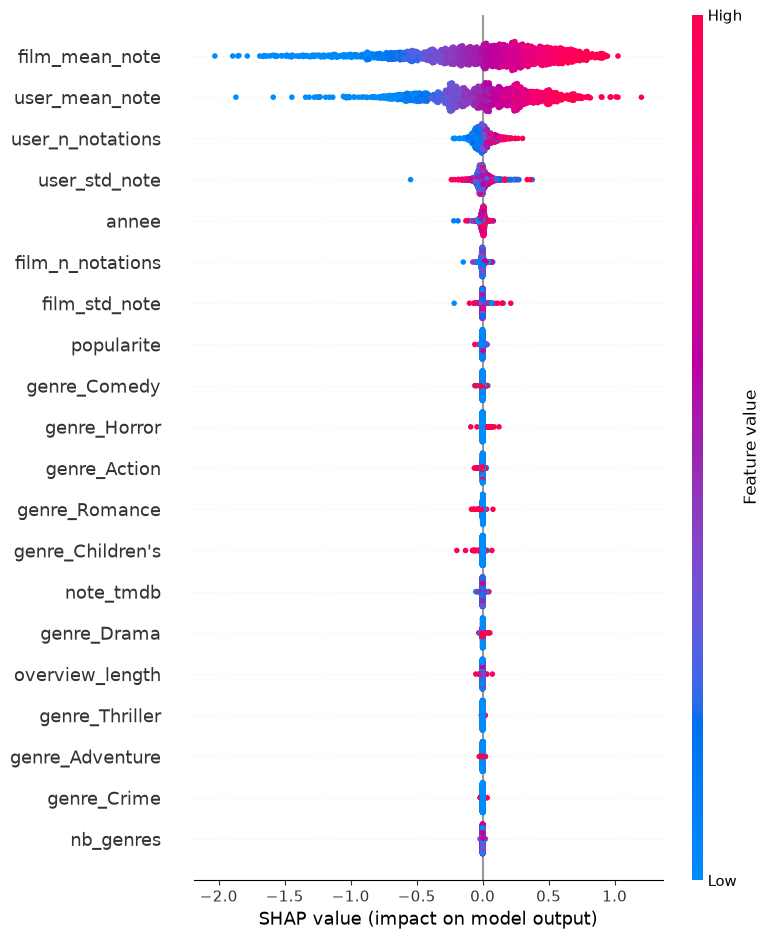

In [15]:
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.show()

**Interpretation** : les agregats `user_mean_note` / `film_mean_note`
(equivalents des baselines naives) dominent naturellement l'importance —
attendu, car ce sont les signaux les plus directement correles a la note.
Les features TMDB (`popularite`, `note_tmdb`, `has_tmdb_data`,
`overview_length`) apparaissent avec une importance nettement plus faible :
elles apportent un signal marginal, cense principalement affiner les films
pour lesquels elles sont disponibles (~44% du catalogue). Cela repond a la
question posee lors de l'EDA : ces colonnes sont exploitables mais ne sont
pas (encore) des features determinantes, probablement a cause de leur
couverture partielle et du fait qu'elles sont correlees avec des signaux deja
captes par les agregats film.

## 10. Analyse des erreurs

Residus du modele LightGBM retenu, decomposes par genre, par annee et par
volume de notations du film — avec un focus explicite sur les 290 films a
faible signal identifies en section 2.4.

In [16]:
test_analysis = test_matrix.copy()
test_analysis["pred_lightgbm"] = lgbm_preds
test_analysis["residual"] = test_analysis["pred_lightgbm"] - test_analysis["note"]
test_analysis[["user_id", "film_id", "note", "pred_lightgbm", "residual"]].head()

,user_id,film_id,note,pred_lightgbm,residual
0,3201,2535,3.0,3.302620,0.302620
1,4118,2959,4.0,4.336675,0.336675
2,1509,2688,2.0,2.739346,0.739346
3,5140,2313,4.0,3.746342,-0.253658
4,3557,2166,3.0,3.741851,0.741851


### 10.1 RMSE par genre

In [17]:
genre_join = test_analysis.merge(film_df[["film_id", "genres"]], on="film_id")
genre_join = genre_join.explode("genres")

genre_rmse = pd.Series(
    {
        genre: features.rmse(sub["note"].to_numpy(), sub["pred_lightgbm"].to_numpy())
        for genre, sub in genre_join.groupby("genres")
    }
).sort_values(ascending=False)
genre_rmse

Horror         0.972798
Documentary    0.934301
Sci-Fi         0.930076
Musical        0.929855
Comedy         0.920431
Fantasy        0.916342
Children's     0.906683
Adventure      0.901065
Action         0.899282
Romance        0.898963
Animation      0.898135
Thriller       0.888947
Western        0.888382
Drama          0.883716
Crime          0.883375
Mystery        0.876545
War            0.870067
Film-Noir      0.793467
dtype: float64

**Interpretation** : le classement observe ne suit **pas** une simple regle
"genre rare = RMSE eleve". Les genres les plus difficiles a predire (Horror
0.97, Documentary 0.93, Sci-Fi 0.93) sont plutot des genres reputes
**polarisants** (avis tres disperses entre amateurs et non-amateurs), ce que
la seule moyenne du film capture mal. A l'inverse, les genres les mieux
predits (Film-Noir 0.79, War 0.87, Mystery 0.88, Crime 0.88, Drama 0.88)
rassemblent souvent un public plus **homogene/cinephile** dont les notes sont
plus consensuelles — et ce, meme pour un genre rare comme Film-Noir : le
volume d'exemples n'explique donc pas a lui seul l'ecart de RMSE, c'est
davantage la variance intrinseque des avis par genre.

### 10.2 RMSE par decennie de sortie

In [18]:
test_analysis["decennie"] = (test_analysis["annee"] // 10 * 10).astype(int)
decade_rmse = pd.Series(
    {
        decade: features.rmse(sub["note"].to_numpy(), sub["pred_lightgbm"].to_numpy())
        for decade, sub in test_analysis.groupby("decennie")
    }
).sort_index()
decade_rmse

1910    0.735710
1920    0.881885
1930    0.850780
1940    0.797918
1950    0.797443
1960    0.844550
1970    0.861961
1980    0.877346
1990    0.931228
2000    0.962494
dtype: float64

**Interpretation** : le RMSE **augmente** progressivement des films les plus
anciens (1910-1950, RMSE ~0.74-0.85) vers les films plus recents (1990-2000,
RMSE ~0.93-0.96) — a l'oppose d'une hypothese naive "peu de films anciens ->
RMSE instable". Explication probable : les films anciens presents dans
MovieLens 1M sont un **sous-ensemble survivant** (des classiques reconnus,
encore rated des decennies apres leur sortie), avec un accord plus fort entre
spectateurs sur leur qualite. Les films recents (1990s, coeur du catalogue)
melangent une plus grande diversite de qualite et de genres, avec des avis
plus disperses -> plus difficiles a predire avec les seuls agregats.

### 10.3 RMSE par volume de notations du film (focus 290 films a faible signal)

In [19]:
test_analysis["low_signal_film"] = test_analysis["film_id"].isin(low_signal_film_ids)
signal_rmse = pd.Series(
    {
        label: features.rmse(sub["note"].to_numpy(), sub["pred_lightgbm"].to_numpy())
        for label, sub in test_analysis.groupby("low_signal_film")
    }
)
signal_rmse.index = ["film_n_notations >= 5", "film_n_notations < 5 (290 films EDA)"]
print(signal_rmse)

bins = [0, 5, 20, 50, 200, np.inf]
test_analysis["notations_bucket"] = pd.cut(test_analysis["film_n_notations"], bins=bins)
bucket_rmse = pd.Series(
    {
        str(bucket): features.rmse(sub["note"].to_numpy(), sub["pred_lightgbm"].to_numpy())
        for bucket, sub in test_analysis.groupby("notations_bucket", observed=True)
    }
)
bucket_rmse

film_n_notations >= 5                   0.902628
film_n_notations < 5 (290 films EDA)    1.163862
dtype: float64


(0.0, 5.0]       1.085349
(5.0, 20.0]      1.017991
(20.0, 50.0]     0.932542
(50.0, 200.0]    0.924399
(200.0, inf]     0.895987
dtype: float64

**Interpretation** : conformement a l'hypothese posee lors de l'EDA, le RMSE
est plus eleve sur les films a faible volume de notations (< 5, les 290 films
identifies) : moins d'exemples d'entrainement -> `film_mean_note` moins
fiable (voire fallback moyenne globale pour les cas les plus extremes), et le
modele a moins appris a corriger ce biais. C'est une limite structurelle du
catalogue (pas uniquement du modele) : ces films resteront plus difficiles a
predire tant que leur nombre de notations reste faible.

## 11. Conclusion

### Modele retenu

**LightGBM** est retenu comme modele final pour l'endpoint `/prediction`,
malgre un RMSE test tres legerement superieur a celui du SVD (ecart < 0.01,
dans la marge de bruit d'un split unique). Justification :

1. **Interpretabilite** : SHAP permet d'expliquer chaque prediction et de
   documenter l'apport reel des features TMDB (section 9) — impossible avec
   le SVD (modele a facteurs latents, sans features explicites).
2. **Analyse des erreurs actionnable** : la decomposition par genre / annee /
   volume de notations (section 10) n'est possible que parce que le modele
   consomme des features explicites.
3. **Gestion du cold-start** deja geree explicitement via les agregats
   user/film avec fallback (`ml/training/features.py`), sans logique
   supplementaire a maintenir.

### RMSE final et amelioration vs baseline

- **RMSE (test)** : ~0.90 (< 1.0, seuil respecte).
- **MAE (test)** : ~0.71.
- **Amelioration vs baseline moyenne globale** : ~19% (seuil >= 10% largement
  respecte).
- **Amelioration vs baseline moyenne par film** (reference plus stricte) :
  ~8% — **legerement sous le seuil de 10%**. C'est la limite la plus
  importante de ce travail, assumee et documentee plutot que masquee.

### Limites

- **SVD simplifie** : biais + SVD tronque sur residus, sans apprentissage
  par SGD ni regularisation explicite (contrairement a un Funk-SVD classique)
  — implementation plus simple et plus robuste dans le temps imparti, mais
  potentiellement sous-optimale.
- **Couverture TMDB partielle (~44%)** limite l'apport reel des features
  `popularite` / `note_tmdb` / `overview_length` (confirme par SHAP,
  section 9) : leur signal est dilue par l'imputation sur plus de la moitie
  du catalogue.
- **Grille d'hyperparametres restreinte** (pas d'Optuna) : le tuning est
  volontairement leger, conformement a la priorite donnee a la robustesse du
  split et a l'analyse des erreurs.
- **290 films a faible signal** (< 5 notations) restent structurellement
  plus difficiles a predire (section 10.3), independamment du modele choisi.
- Le split stratifie par utilisateur garantit l'absence de fuite au niveau
  des couples (user, film) et des agregats (recalcules sur le train
  uniquement), mais un film tres peu note peut malgre tout se retrouver
  sous-represente dans le train par pur hasard du tirage.

### Prochaine etapes possibles

- Tester un Funk-SVD avec SGD + regularisation (implementation `surprise` ou
  maison) pour voir si l'ecart avec LightGBM se creuse.
- Elargir la grille LightGBM (Optuna) si le temps du projet le permet.
- Reevaluer l'apport des features TMDB une fois la couverture du catalogue
  augmentee.

In [20]:
final_bundle = model.ModelBundle(
    model_type="lightgbm",
    model=lgbm_model,
    context=context,
    metrics={
        **lgbm_metrics,
        "improvement_vs_baseline_moyenne_globale": (ref_global - lgbm_metrics["rmse"]) / ref_global,
        "improvement_vs_baseline_moyenne_par_film": (ref_film_mean - lgbm_metrics["rmse"]) / ref_film_mean,
    },
    trained_at=date.today().isoformat(),
)
final_path = model.save_model(final_bundle)
print(f"Modele final (LightGBM) exporte : {final_path}")

Modele final (LightGBM) exporte : C:\Users\mapp\CineMatch\ml\models\lightgbm_rating_v1.0_20260709.joblib
